In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from gymnasium.vector import AsyncVectorEnv
import numpy as np
import os
from datetime import datetime
import logging
import optuna
from models import ppo
from env import mbb
import ast


In [2]:

def weights_init_he(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_uniform_(m.weight, a=0, mode='fan_in', nonlinearity='relu')
        torch.nn.init.constant_(m.bias, 0)
def load_hyperparameters(file_path):
    """
    Load hyperparameters from a Python dictionary string in a text file.
    
    Args:
        file_path (str): Path to the hyperparameters text file.
    
    Returns:
        dict: Dictionary of hyperparameters.
    """
    with open(file_path, 'r') as f:
        hyperparams_str = f.read()
    try:
        hyperparams = ast.literal_eval(hyperparams_str)
    except (SyntaxError, ValueError) as e:
        raise ValueError(f"Error parsing hyperparameters file: {e}")
    return hyperparams


In [3]:

def train_ppo(trial):

    K_epochs = trial.suggest_int('K_epochs', 2, 20)
    eps_clip = trial.suggest_float('eps_clip', 0.05, 0.3)
    gamma = trial.suggest_float('gamma', 0.9, 0.999)
    lr_actor = trial.suggest_float('lr_actor', 5e-6, 1e-4)
    lr_critic = trial.suggest_float('lr_critic', 5e-6, 1e-4)
    gae_lambda = trial.suggest_float('gae_lambda', 0.8, 1.0)


    w_compliance = trial.suggest_float('w_compliance', 0.1, 1.0)
    w_density_high = trial.suggest_float('w_density_high', 1.0, 10.0)
    w_density_low = trial.suggest_float('w_density_low', 0.1, 1.0)
    w_total_mass = trial.suggest_float('w_total_mass', 0.5, 3.0)
    w_entropy = trial.suggest_float('w_entropy', 0.1, 1.0)
    
 
    has_continuous_action_space = False
    action_std = None  # Not used for discrete action spaces
    random_seed = 0 

    reward_weights={
            'w_compliance': w_compliance,
            'w_density_high': w_density_high,
            'w_density_low': w_density_low,
            'w_total_mass': w_total_mass,
            'w_entropy': w_entropy
        }
    
    def make_env():
        return mbb.BeamOptimizationEnv(width=4, height=4, density=0.4, step_size=0.05, optimal_density=0.5, reward_weights=reward_weights)
    env_name = "BeamOptimizationEnv"
    num_envs = 16
    env_fns = [make_env for _ in range(num_envs)]  
    vector_env = AsyncVectorEnv(env_fns)
    print(type(vector_env))
    # Get state and action dimensions
    state_dim = vector_env.single_observation_space.shape[0]
    print(f"State dimension: {state_dim}")

    if has_continuous_action_space:
        action_dim = vector_env.single_action_space.shape[0]
    else:
        action_dim = vector_env.single_action_space.n

    # Initialize PPO agent
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ppo_agent = ppo.PPO(
        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        K_epochs=K_epochs,
        eps_clip=eps_clip,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=action_std,
        gae_lambda=gae_lambda,
        num_envs=num_envs,
        device=device
    )


    env = mbb.BeamOptimizationEnv(width=4, height=4)

    print_running_reward = 0
    log_running_reward = 0
    print_running_episodes = 0
    max_ep_len = env.width * env.height * 10 
    max_training_timesteps = int(360) 

    log_running_episodes = 0
    update_timestep = max_ep_len



    #### Initialize Logging Variables ####
    timestep = 0
    running_reward = 0
    avg_length = 0
    reward_history = []
    compliance_history = []
    i_episode = 0

    while timestep < max_training_timesteps+1:
        state, info = vector_env.reset()
        ep_reward = np.zeros(num_envs)
        done_flags = np.array([False] * num_envs)

        for t_step in range(1, max_ep_len + 1):
            actions, logprobs, state_values = ppo_agent.select_action(state)

            try:
                states_new, rewards, dones, truncateds, infos = vector_env.step(actions)
                #print(f"action takens")
            except Exception as e:
                print(f"Error during environment step: {e}")
                break

            dones_combined = np.logical_or(dones, truncateds)
            if not ppo_agent.has_continuous_action_space:
                actions_tensor = torch.LongTensor(actions).to(ppo_agent.device)
            else:
                actions_tensor = torch.FloatTensor(actions).to(ppo_agent.device)

            ppo_agent.buffer.store(
                states=torch.FloatTensor(state).to(ppo_agent.device),
                actions=actions_tensor,
                logprobs=logprobs,
                rewards=torch.FloatTensor(rewards).to(ppo_agent.device),
                state_values=state_values,
                is_terminals=torch.tensor(dones_combined, dtype=torch.bool).to(ppo_agent.device)
            )
            ep_reward += rewards
            state = states_new
            #timestep += num_envs
            timestep +=1  

            if timestep % update_timestep == 0:
                ppo_agent.update()

            if dones_combined.all():
                compliance_values = infos['compliance']
                compliance_history.extend(compliance_values)  # Store all compliance values
                #print(f"compliance values is {compliance_values}")
                #episode_compl_min = min(compliance_values)
                #print(f"episode compl avg {episode_compl_avg}")
                break

        print_running_reward += ep_reward
        print_running_episodes += 1
        # compliance_history.append( episode_compl_min)
        #print(f"compliance history is {compliance_history}")
        avg_compliance = np.mean(compliance_history[-num_envs:])  
        print(f"compl average is {avg_compliance}")
        log_running_reward += ep_reward
        log_running_episodes += 1

        i_episode += 1

    env.close()
    vector_env.close()
    
    return np.mean(compliance_history)


In [4]:
def main():
    study = optuna.create_study(direction='minimize', study_name='PPO_Optimization')
    
    study.optimize(train_ppo, n_trials=100)  
    
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial
    
    print("  Value: ", trial.value)
    
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    with open("best_hyperparameters.txt", "w") as f:
        f.write(str(study.best_params))




In [5]:
if __name__ == "__main__":
    mp.set_start_method('spawn', force=True) 
    main()

[I 2024-12-23 23:10:19,961] A new study created in memory with name: PPO_Optimization


<class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State dimension: 16
compl average is 123.26738859054427
compl average is 116.80380318383787
compl average is 129.367859035653


[I 2024-12-23 23:10:27,540] Trial 0 finished with value: 123.14635027001172 and parameters: {'K_epochs': 12, 'eps_clip': 0.05462435592263422, 'gamma': 0.9034520757981197, 'lr_actor': 2.258569691312245e-05, 'lr_critic': 8.569156388580105e-05, 'gae_lambda': 0.8946534106792345, 'w_compliance': 0.8638876934237115, 'w_density_high': 9.625816311798847, 'w_density_low': 0.9557197510889651, 'w_total_mass': 1.871975031962194, 'w_entropy': 0.2475929572323345}. Best is trial 0 with value: 123.14635027001172.


<class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State dimension: 16
compl average is 420.24093831805556
compl average is 350.8140900999683
compl average is 187.11395083331564


[I 2024-12-23 23:10:34,002] Trial 1 finished with value: 319.3896597504465 and parameters: {'K_epochs': 14, 'eps_clip': 0.18359652441484153, 'gamma': 0.9402661447064684, 'lr_actor': 1.7280222389938005e-05, 'lr_critic': 6.2090645407283e-05, 'gae_lambda': 0.9415340467621689, 'w_compliance': 0.8582265137919036, 'w_density_high': 2.3851524860714743, 'w_density_low': 0.8400340976678766, 'w_total_mass': 2.54354008419568, 'w_entropy': 0.41415850395044085}. Best is trial 0 with value: 123.14635027001172.


...

<class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State dimension: 16
compl average is 384415036.03297585
compl average is 315764084.6558979
compl average is 239073529.49698576


[I 2024-12-23 23:20:52,872] Trial 98 finished with value: 313084216.7286199 and parameters: {'K_epochs': 9, 'eps_clip': 0.2831998479962896, 'gamma': 0.9389143381673218, 'lr_actor': 1.2244442783117778e-05, 'lr_critic': 4.144949050284171e-05, 'gae_lambda': 0.839172295198991, 'w_compliance': 0.6115079731953357, 'w_density_high': 9.187869987125268, 'w_density_low': 0.7145220045557531, 'w_total_mass': 1.649738311424571, 'w_entropy': 0.734261228664142}. Best is trial 46 with value: 61.24118003342318.


<class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State dimension: 16
compl average is 315972903.5487666
compl average is 203085266.10640177
compl average is 139891635.3569028


[I 2024-12-23 23:20:59,120] Trial 99 finished with value: 219649935.00402376 and parameters: {'K_epochs': 7, 'eps_clip': 0.18278923192487206, 'gamma': 0.9369381951941298, 'lr_actor': 6.429700333239915e-06, 'lr_critic': 2.9591363686614683e-05, 'gae_lambda': 0.8069445249226617, 'w_compliance': 0.641249650871228, 'w_density_high': 8.672711586715911, 'w_density_low': 0.741226232845133, 'w_total_mass': 1.4456755099915497, 'w_entropy': 0.8204537863439711}. Best is trial 46 with value: 61.24118003342318.


Number of finished trials:  100
Best trial:
  Value:  61.24118003342318
  Params: 
    K_epochs: 19
    eps_clip: 0.1560054116302963
    gamma: 0.9541033156990307
    lr_actor: 1.534069415636938e-05
    lr_critic: 5.7160372295955113e-05
    gae_lambda: 0.8486921477985604
    w_compliance: 0.7742947255672104
    w_density_high: 5.634912144964039
    w_density_low: 0.6367337858475912
    w_total_mass: 1.4913119246676363
    w_entropy: 0.9018999960713338


In [6]:
'''
best_params = {'K_epochs': 96,
    'eps_clip': 0.3955747683761253,
    'gamma': 0.9272139499875774,
    'lr_actor': 0.0006427887624292107,
    'lr_critic': 0.0003281045462174873,
    'gae_lambda': 0.9778136815123651,
    'w_compliance': 0.7854333362955717,
    'w_density_high': 4.224123274206661,
    'w_density_low': 0.3426752536066723,
    'w_total_mass': 1.2483019365554737,
    'w_entropy': 0.3387358826217064}
    #'''

"\nbest_params = {'K_epochs': 96,\n    'eps_clip': 0.3955747683761253,\n    'gamma': 0.9272139499875774,\n    'lr_actor': 0.0006427887624292107,\n    'lr_critic': 0.0003281045462174873,\n    'gae_lambda': 0.9778136815123651,\n    'w_compliance': 0.7854333362955717,\n    'w_density_high': 4.224123274206661,\n    'w_density_low': 0.3426752536066723,\n    'w_total_mass': 1.2483019365554737,\n    'w_entropy': 0.3387358826217064}\n    #"

In [7]:
mp.set_start_method('spawn', force=True)

hyperparams_file = 'best_hyperparameters.txt'
best_params = load_hyperparameters(hyperparams_file)

# Extract PPO hyperparameters
K_epochs = best_params['K_epochs']
eps_clip = best_params['eps_clip']
gamma = best_params['gamma']
lr_actor = best_params['lr_actor']
lr_critic = best_params['lr_critic']
gae_lambda = best_params['gae_lambda']

K_epochs = best_params['K_epochs']
eps_clip = best_params['eps_clip']
gamma = best_params['gamma']
lr_actor = best_params['lr_actor']
lr_critic = best_params['lr_critic']


reward_weights = {
    'w_compliance': best_params['w_compliance'],
    'w_density_high': best_params['w_density_high'],
    'w_density_low': best_params['w_density_low'],
    'w_total_mass': best_params['w_total_mass'],
    'w_entropy': best_params['w_entropy']
}

# Number of parallel environments
num_envs = 16
def make_env():
    return mbb.BeamOptimizationEnv(width=4, height=4, density=0.4, step_size=0.05, optimal_density=0.5, reward_weights=reward_weights)
# Create environments
env_fns = [make_env for _ in range(num_envs)]
vector_env = AsyncVectorEnv(env_fns)

print(f"VectorEnv type: {type(vector_env)}")

# Get state and action dimensions
state_dim = vector_env.single_observation_space.shape[0]
print(f"State dimension: {state_dim}")

# Determine action dimension based on action space type
has_continuous_action_space = False  # Set as per your environment
if has_continuous_action_space:
    action_dim = vector_env.single_action_space.shape[0]
else:
    action_dim = vector_env.single_action_space.n

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize PPO agent with loaded hyperparameters
ppo_agent = ppo.PPO(
    state_dim=state_dim,
    action_dim=action_dim,
    lr_actor=lr_actor,
    lr_critic=lr_critic,
    gamma=gamma,
    K_epochs=K_epochs,
    eps_clip=eps_clip,
    gae_lambda=0.95,
    has_continuous_action_space=has_continuous_action_space,
    action_std_init=None,
    num_envs=num_envs,
    device=device
)


env = mbb.BeamOptimizationEnv(width=4, height=4, density=0.4, step_size=0.05, optimal_density=0.5, reward_weights=reward_weights)
def make_env():
    return mbb.BeamOptimizationEnv(width=4, height=4, density=0.4, step_size=0.05, optimal_density=0.5, reward_weights=reward_weights)
env_name = "BeamOptimizationEnv"
num_envs = 16
env_fns = [make_env for _ in range(num_envs)]
max_ep_len = env.width * env.height * 10

# Initialize logging
logging.basicConfig(
    filename='optuna_logs.log',
    filemode='w',
    format='%(asctime)s - %(levelname)s - %(message)s',
    level=logging.INFO
)

# Setup logging directories
log_dir = "PPO_logs"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

log_dir = os.path.join(log_dir, "BeamOptimizationEnv")
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

# Determine run number based on existing log files
current_num_files = next(os.walk(log_dir))[2]
run_num = len(current_num_files)

# Create a new log file for this run
log_f_name = os.path.join(log_dir, f'PPO_BeamOptimizationEnv_log_{run_num}.csv')
print(f"Current logging run number for BeamOptimizationEnv: {run_num}")
print(f"Logging at: {log_f_name}")

# Setup checkpointing directories
run_num_pretrained = 0  # Change this to prevent overwriting weights

checkpoint_dir = "PPO_preTrained"
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

checkpoint_dir = os.path.join(checkpoint_dir, "BeamOptimizationEnv")
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

checkpoint_path = os.path.join(checkpoint_dir, f"PPO_BeamOptimizationEnv_{0}_{run_num_pretrained}.pth")
print(f"Save checkpoint path: {checkpoint_path}")

# Open logging file
log_f = open(log_f_name, "w+")
log_f.write('episode,timestep,avg_reward\n')

# Initialize training variables
start_time = datetime.now().replace(microsecond=0)
print(f"Started training at (GMT): {start_time}")

timestep = 0
print_running_reward = 0
log_running_reward = 0
print_running_episodes = 0
running_reward = 0
running_episodes = 0
avg_compl_timestep = []
i_episode = 0

max_training_timesteps = int(1e5)  
update_timestep = max_ep_len  
print_freq = max_ep_len * 2      
log_freq = max_ep_len * 2        
save_model_freq = int(2e3)       
log_running_episodes = 0

state, infos = vector_env.reset()

while timestep < max_training_timesteps+1:
        # Reset all environments and unpack the observations and info
        state, info = vector_env.reset()
        ep_reward = np.zeros(num_envs)
        done_flags = np.array([False] * num_envs)

        for t_step in range(1, max_ep_len + 1):
            # Select actions for all environments
            actions, logprobs, state_values = ppo_agent.select_action(state)

            # Take actions in all environments
            try:
                states_new, rewards, dones, truncateds, infos = vector_env.step(actions)
                #print(f"action takens")
            except Exception as e:
                print(f"Error during environment step: {e}")
                break

            # Combine done flags
            dones_combined = np.logical_or(dones, truncateds)

            # Store transitions in the buffer
            if not ppo_agent.has_continuous_action_space:
                # For discrete actions
                actions_tensor = torch.LongTensor(actions).to(ppo_agent.device)
            else:
                # For continuous actions
                actions_tensor = torch.FloatTensor(actions).to(ppo_agent.device)

            ppo_agent.buffer.store(
                states=torch.FloatTensor(state).to(ppo_agent.device),
                actions=actions_tensor,
                logprobs=logprobs,
                rewards=torch.FloatTensor(rewards).to(ppo_agent.device),
                state_values=state_values,
                is_terminals=torch.tensor(dones_combined, dtype=torch.bool).to(ppo_agent.device)
            )
            ep_reward += rewards
            state = states_new
            #timestep += num_envs
            timestep +=1  
            # Update PPO agent if enough timesteps have passed

            # update PPO agent

            if timestep % update_timestep == 0:
                ppo_agent.update()

            # if continuous action space; then decay action std of ouput action distribution
            if has_continuous_action_space and timestep % action_std_decay_freq == 0:
                ppo_agent.decay_action_std(action_std_decay_rate, min_action_std)

            # log in logging file
            if timestep % log_freq == 0:

                # log average reward till last episode
                log_avg_reward = log_running_reward / log_running_episodes
                log_avg_reward = np.mean(log_avg_reward)
                log_avg_reward = round(log_avg_reward, 4)

                log_f.write('{},{},{}\n'.format(i_episode, timestep, log_avg_reward))
                log_f.flush()

                log_running_reward = 0
                log_running_episodes = 0


            # printing average reward
            if timestep % print_freq == 0:
                # print average reward till last episode
                print_avg_reward = print_running_reward / print_running_episodes
                print_avg_reward = np.mean(print_avg_reward)
                print_avg_reward = round(print_avg_reward, 2)

                print("Episode : {} \t\t Timestep : {} \t\t Average Reward : {}".format(i_episode, timestep, print_avg_reward))

                print_running_reward = 0
                print_running_episodes = 0
                
            # save model weights
            if timestep % save_model_freq == 0:
                print("--------------------------------------------------------------------------------------------")
                print("saving model at : " + checkpoint_path)
                ppo_agent.save(checkpoint_path)
                print("model saved")
                print("Elapsed Time  : ", datetime.now().replace(microsecond=0) - start_time)
                print("--------------------------------------------------------------------------------------------")
                
            # break; if the episode is over
            if dones_combined.all():
                break

        print_running_reward += ep_reward
        print_running_episodes += 1

        log_running_reward += ep_reward
        log_running_episodes += 1

        i_episode += 1




# Close logging file and environments
log_f.close()
vector_env.close()

# Print total training time
print("============================================================================================")
end_time = datetime.now().replace(microsecond=0)
print(f"Finished training at (GMT): {end_time}")
print(f"Total training time: {end_time - start_time}")
print("============================================================================================")


VectorEnv type: <class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State dimension: 16
Current logging run number for BeamOptimizationEnv: 10
Logging at: PPO_logs/BeamOptimizationEnv/PPO_BeamOptimizationEnv_log_10.csv
Save checkpoint path: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
Started training at (GMT): 2024-12-23 23:21:02
Episode : 1 		 Timestep : 320 		 Average Reward : 25.59
Episode : 3 		 Timestep : 640 		 Average Reward : 41.63
Episode : 5 		 Timestep : 960 		 Average Reward : 33.86
Episode : 7 		 Timestep : 1280 		 Average Reward : 39.29
Episode : 9 		 Timestep : 1600 		 Average Reward : 41.61
Episode : 11 		 Timestep : 1920 		 Average Reward : 52.5
--------------------------------------------------------------------------------------------
saving model at : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
model saved
Elapsed Time  :  0:00:09
------------------------------------------------------------------------------------

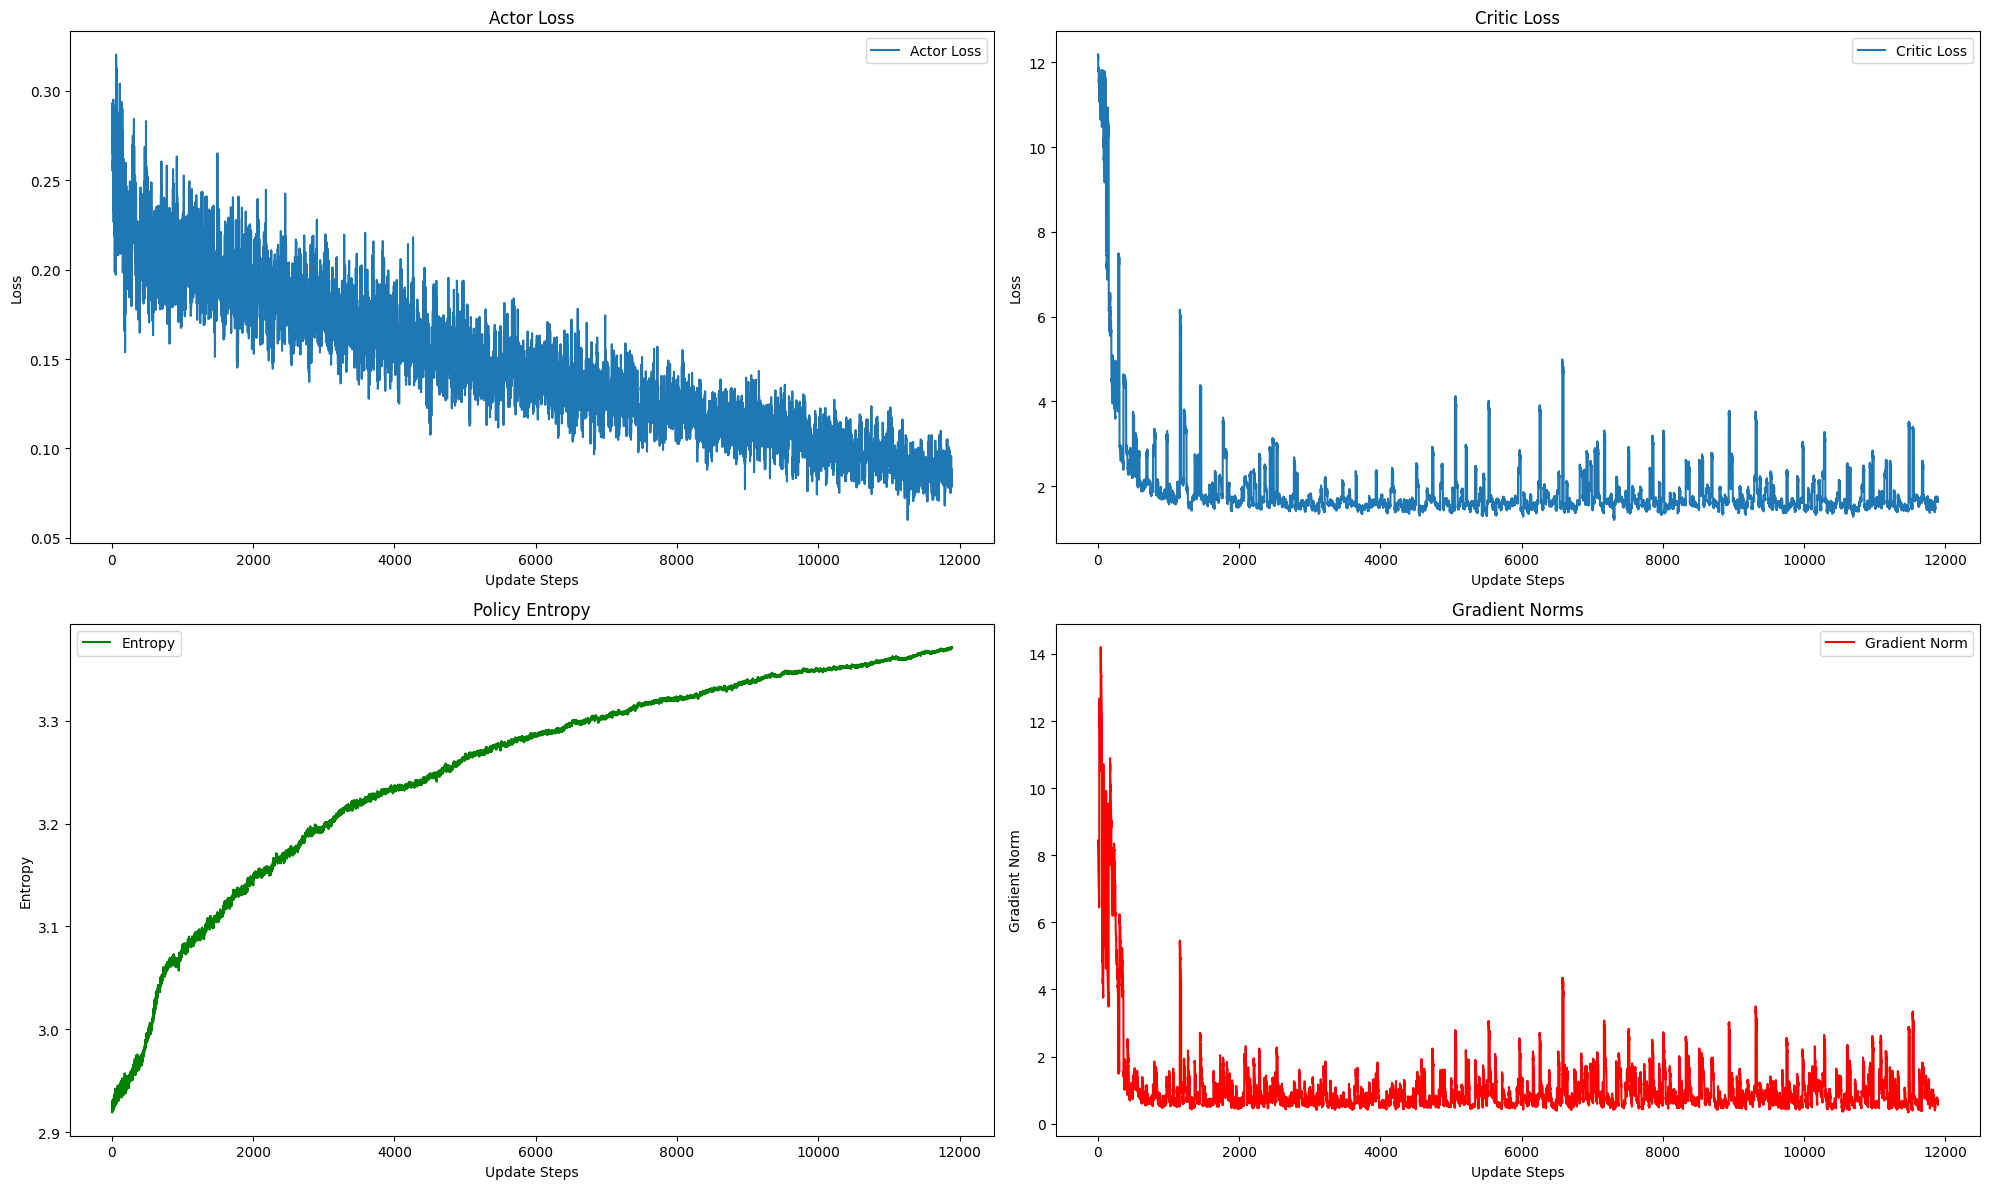

In [8]:
ppo_agent.plot_metrics()

 state dim is 16
 action dim is 32
loading network from : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
--------------------------------------------------------------------------------------------


/home/mihovil/mihovil/structural_optimization/src/models/ppo.py:352: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devi

number of changed cells in the episode is 160
Episode: 1 		 Reward: -9.56
number of changed cells in the episode is 160
Episode: 2 		 Reward: -31.0
number of changed cells in the episode is 160
Episode: 3 		 Reward: -38.05
number of changed cells in the episode is 160
Episode: 4 		 Reward: -35.89
number of changed cells in the episode is 160
Episode: 5 		 Reward: -25.52
number of changed cells in the episode is 160
Episode: 6 		 Reward: -38.39
number of changed cells in the episode is 160
Episode: 7 		 Reward: -23.05
number of changed cells in the episode is 160
Episode: 8 		 Reward: -8.17
number of changed cells in the episode is 160
Episode: 9 		 Reward: -42.04
number of changed cells in the episode is 160
Episode: 10 		 Reward: 8.9
average test reward : -24.28
loading data from : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_0.csv
File PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_0.csv is empty. Skipping.
-----------------------------------------------------

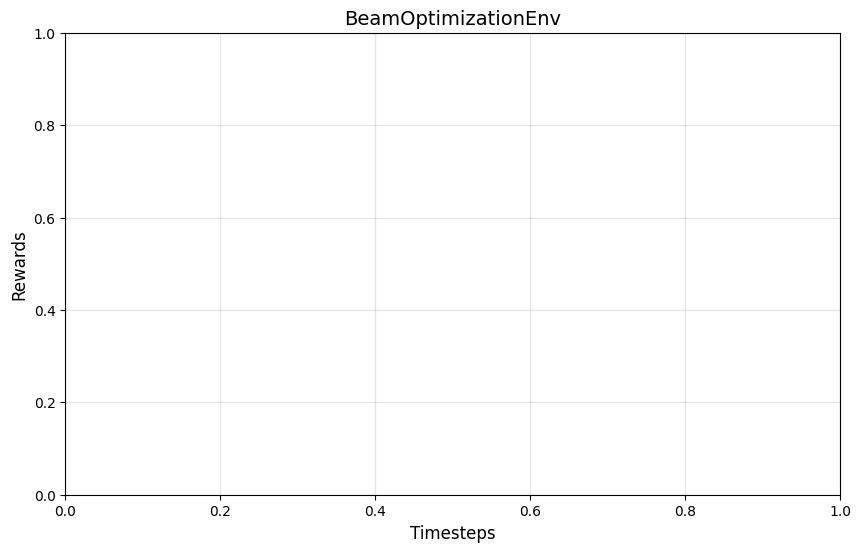

Loading network from: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth


/home/mihovil/mihovil/structural_optimization/src/models/ppo.py:352: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devi

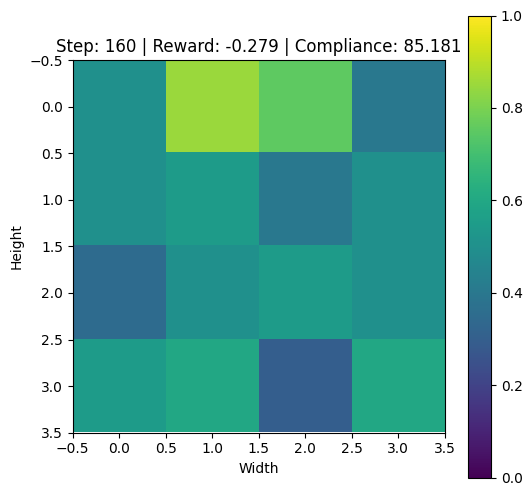

Episode: 1 		 Reward: -27.92


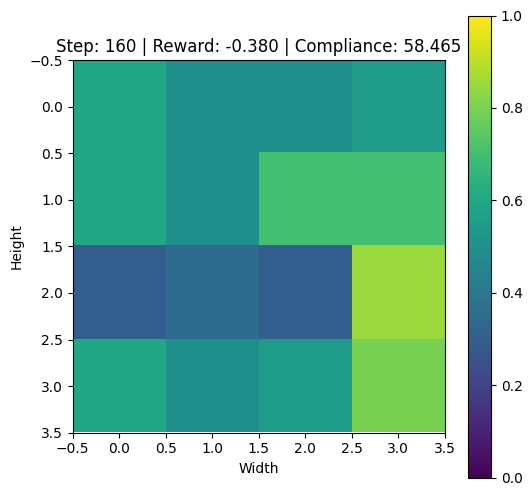

Episode: 2 		 Reward: -30.88


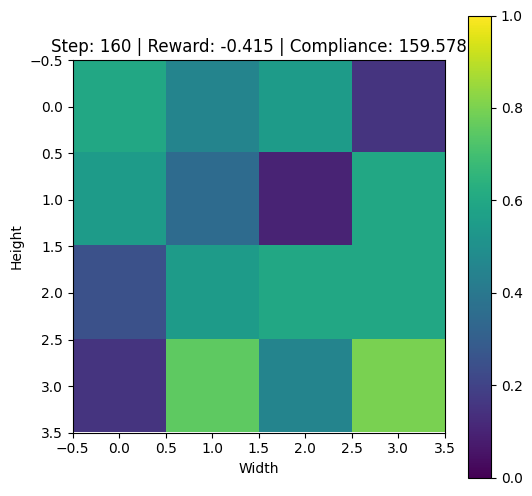

Episode: 3 		 Reward: -17.08


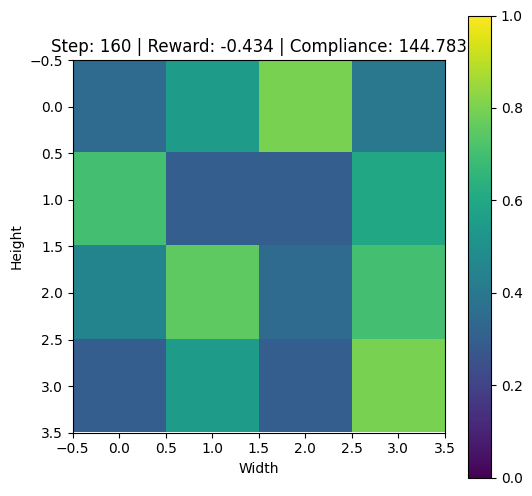

Episode: 4 		 Reward: -26.93


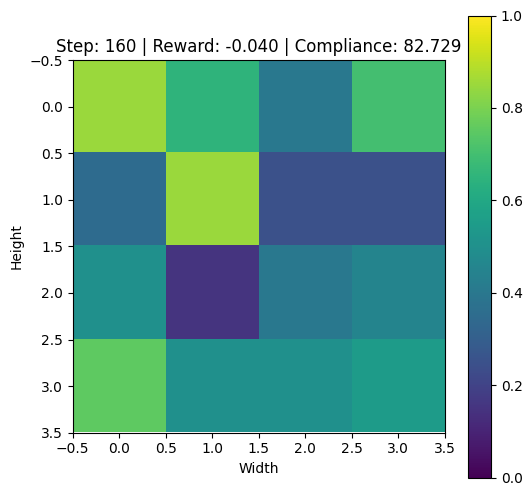

Episode: 5 		 Reward: -13.27


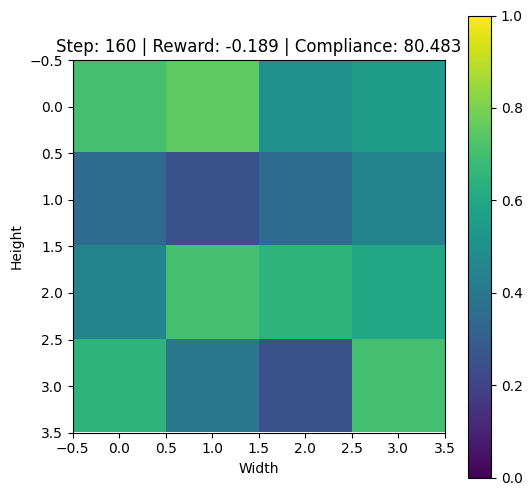

Episode: 6 		 Reward: -21.01


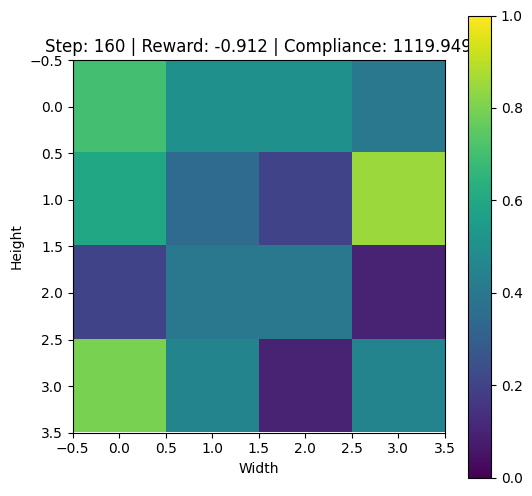

Episode: 7 		 Reward: -31.57


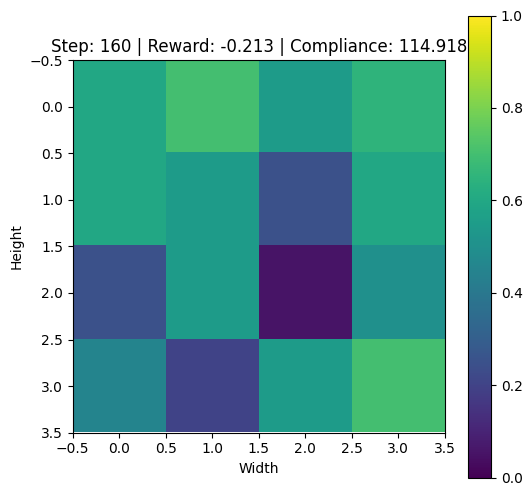

Episode: 8 		 Reward: -15.93


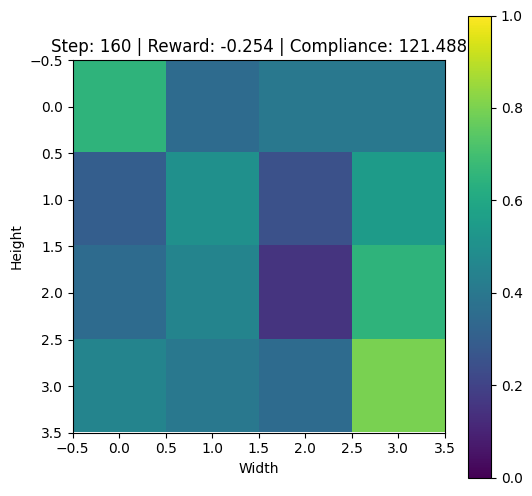

Episode: 9 		 Reward: -12.39
Average test reward: -19.70


In [9]:


print("============================================================================================")


#################################### Testing ###################################


################## hyperparameters ##################

env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
max_ep_len = 1000
action_std = None




total_test_episodes = 10    # total num of testing episodes


K_epochs = best_params['K_epochs']
eps_clip = best_params['eps_clip']
gamma = best_params['gamma']
lr_actor = best_params['lr_actor']
lr_critic = best_params['lr_critic']

#####################################################


env = mbb.BeamOptimizationEnv(width=4, height=4)

state_dim = env.observation_space.shape[0]
print(f" state dim is {state_dim}")

if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n
print(f" action dim is {action_dim}")


ppo_agent = ppo.PPO(
        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        K_epochs=K_epochs,
        eps_clip=eps_clip,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=action_std,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=device
    )


# preTrained weights directory

random_seed = 0             
run_num_pretrained = 0      


directory = "PPO_preTrained" + '/' + env_name + '/'
checkpoint_path = directory + "PPO_{}_{}_{}.pth".format(env_name, random_seed, run_num_pretrained)
print("loading network from : " + checkpoint_path)

ppo_agent.load(checkpoint_path)

print("--------------------------------------------------------------------------------------------")



test_running_reward = 0

for ep in range(1, total_test_episodes+1):
    ep_reward = 0
    state,_ = env.reset()
    for t in range(1, max_ep_len+1):
        action,_,_ = ppo_agent.select_action(state)
        state, reward, done, truncated, info = env.step(action)
        ep_reward += reward
        
        if done:
            print(f"number of changed cells in the episode is {info['num_of_changed_cells']}")
            break

    # clear buffer    
    ppo_agent.buffer.clear()

    test_running_reward +=  ep_reward
    print('Episode: {} \t\t Reward: {}'.format(ep, round(ep_reward, 2)))
    ep_reward = 0

env.close()


print("============================================================================================")

avg_test_reward = test_running_reward / total_test_episodes
avg_test_reward = round(avg_test_reward, 2)
print("average test reward : " + str(avg_test_reward))

print("============================================================================================")

import os
import pandas as pd
import matplotlib.pyplot as plt

print("============================================================================================")

env_name = 'BeamOptimizationEnv'

fig_num = 0     #### change this to prevent overwriting figures in same env_name folder

plot_avg = True    # plot average of all runs; else plot all runs separately

fig_width = 10
fig_height = 6

# smooth out rewards to get a smooth and a less smooth (var) plot lines
window_len_smooth = 50
min_window_len_smooth = 1
linewidth_smooth = 1.5
alpha_smooth = 1

window_len_var = 5
min_window_len_var = 1
linewidth_var = 2
alpha_var = 0.1

colors = ['red', 'blue', 'green', 'orange', 'purple', 'olive', 'brown', 'magenta', 'cyan', 'crimson', 'gray', 'black']

# make directory for saving figures
figures_dir = "PPO_figs"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

# make environment directory for saving figures
figures_dir = figures_dir + '/' + env_name + '/'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

fig_save_path = figures_dir + '/PPO_' + env_name + '_fig_' + str(fig_num) + '.png'

# get number of log files in directory
log_dir = "PPO_logs" + '/' + env_name + '/'
current_num_files = next(os.walk(log_dir))[2]
num_runs = len(current_num_files)

all_runs = []

for run_num in range(num_runs):
    log_f_name = log_dir + '/PPO_' + env_name + "_log_" + str(run_num) + ".csv"
    print("loading data from : " + log_f_name)
    if os.path.getsize(log_f_name) > 0:  
        data = pd.read_csv(log_f_name)
        data = pd.DataFrame(data)
        print("data shape : ", data.shape)
        all_runs.append(data)
    else:
        print(f"File {log_f_name} is empty. Skipping.")
    print("--------------------------------------------------------------------------------------------")

ax = plt.gca()


# ax.set_yticks(np.arange(0, 1800, 200))
# ax.set_xticks(np.arange(0, int(4e6), int(5e5)))

ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.2)

ax.set_xlabel("Timesteps", fontsize=12)
ax.set_ylabel("Rewards", fontsize=12)

plt.title(env_name, fontsize=14)

fig = plt.gcf()
fig.set_size_inches(fig_width, fig_height)

print("============================================================================================")

plt.savefig(fig_save_path)
print("figure saved at : ", fig_save_path)

print("============================================================================================")

plt.show()




# Hyperparameters for inference
env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
max_ep_len = 1000
total_inference_episodes = 10  # Total number of inference episodes

# Initialize environment
env = mbb.BeamOptimizationEnv(width=4, height=4)

# State and action space dimensions
state_dim = env.observation_space.shape[0]
if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n

# Initialize PPO agent
ppo_agent = ppo.PPO(        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        K_epochs=K_epochs,
        eps_clip=eps_clip,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=action_std,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=device)
# Load pre-trained model
random_seed = 0             
run_num_pretrained = 0     
checkpoint_path = f"PPO_preTrained/{env_name}/PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth"
print(f"Loading network from: {checkpoint_path}")
ppo_agent.load(checkpoint_path)

test_running_reward = 0
for ep in range(1,10):
    state,_ = env.reset()
    ep_reward = 0

    for t in range(1, max_ep_len + 1):
        action, _, _ = ppo_agent.select_action(state)
        state, reward, done, truncated, _ = env.step(action)
        ep_reward += reward
        
        #env.render()
        
        if done:
            env.render()
            break

    test_running_reward += ep_reward
    print(f'Episode: {ep} \t\t Reward: {round(ep_reward, 2)}')

avg_test_reward = test_running_reward / total_inference_episodes
print(f"Average test reward: {avg_test_reward:.2f}")

env.close()